# **Package installation, import and enviroment setup**

In [ ]:
import os
import cv2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
from ultralytics import YOLO
from roboflow import Roboflow
import albumentations as A

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset download** "tesi Computer Vision Dataset" from roboflow

In [ ]:
def download_dataset(api_key, workspace, project, version, version_yolo):
  rf = Roboflow(api_key=api_key)
  project = rf.workspace(workspace).project(project)
  dataset = project.version(version).download(version_yolo)

API_KEY_ROBOFLOW = "API_KEY_ROBOFLOW"
NOMBRE_WORKSPACE = "sebastians-workspace-hr8j3"
NOMBRE_PROYECTO = "tesicomputervisiondatasetv1"
VERSION_DATASET = 1
VERSION_YOLO = "yolov8"

download_dataset(API_KEY_ROBOFLOW, NOMBRE_WORKSPACE, NOMBRE_PROYECTO, VERSION_DATASET, VERSION_YOLO)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tesiComputerVisionDatasetV1-1 in yolov8:: 100%|██████████| 19176/19176 [00:06<00:00, 2760.23it/s]


# **Global variables**

In [ ]:
from pathlib import Path
from typing import Final

PATH_BASE: Final[Path] = Path.cwd()

PATH_TEST_LABELS:  Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"test"/"labels"
PATH_TRAIN_LABELS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"labels"
PATH_VALID_LABELS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid"/"labels"

PATH_TEST_IMAGES:  Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"test"/"images"
PATH_TRAIN_IMAGES: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"images"
PATH_VALID_IMAGES: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid"/"images"

CLASSES: Final[list[str]] = ["bus", "construction", "cyclist", "pedestrian", "vehicle"]

CLASSES_NUMBERS: Final[dict[int,str]] = {0: "bus", 1:"construction", 2:"cyclist", 3:"pedestrian", 4:"vehicle"}

In [ ]:
from pathlib import Path

def validate_dataset_paths(paths: dict[str, Path]) -> None:
    """
    Valida que todas las rutas del dataset existan y sean directorios.

    Args:
        paths: Diccionario {nombre_descriptivo: Path}

    Raises:
        NotADirectoryError: Si una ruta existe pero no es directorio.
    """

    for name, path in paths.items():
        if path.exists() and not path.is_dir():
            raise NotADirectoryError(f" '{name}' exist but not a directory: {path}")
        elif path.exists() and path.is_dir():
            print(f"{path} exist")
        elif not path.exists():
            path.mkdir(parents=True, exist_ok=True)
            print(f"{path} created \n")


In [ ]:
DATASET_PATHS = {
    "test/labels":  PATH_TEST_LABELS,
    "train/labels": PATH_TRAIN_LABELS,
    "valid/labels": PATH_VALID_LABELS,
    "test/images":  PATH_TEST_IMAGES,
    "train/images": PATH_TRAIN_IMAGES,
    "valid/images": PATH_VALID_IMAGES,
}

validate_dataset_paths(DATASET_PATHS)

# **Classes count from images**

In [ ]:
from typing import Final

def counting_classes_frecuency(path_images :str, classes :dict[int, str]) -> dict[str, int]:
  '''
  It counts the number of images in each sub-dataset

  Args:
    path_images (str): The path to the images.
    classes (dict[int, str]): A dictionary of the classes.

  Returns:
    A dictionary with the number of images in each sub-dataset.

  Raises:
    FileNotFoundError: If the file is not found.
    ValueError: If the class is not in the dictionary.
    OSError: If there is an error reading the file.
    Exception: If there is an error.

  '''

  tag_files: Final[Path]  = Path(path_images)
  files: Final[list[Path]] = tag_files.glob('*.txt')

  classes_count: dict[str, int] = dict()
  classes_count = {name: 0 for name in classes.values()}

  for file in files:

    found_clases: set[int] = set()

    try:

      with open(file, 'r') as f:

        for linea in f:
          if linea:

            number_class = int(float(linea.split()[0]))
            class_name = classes[number_class]

            if number_class not in found_clases:
              found_clases.add(number_class)
              classes_count[class_name] += 1

    except FileNotFoundError:
        print(f"{file} not found: \n {FileNotFoundError}")
    except ValueError as ve:
        print(f"Invalid class in file: \n {file}: in line: \n {linea}, exception: {ve}")
    except OSError:
      print(f"Error reading file: \n {file}")
    except Exception as e:
        print(f"An error occurred: \n {e} Erro: \n {type(e).__name__}")
    finally:
      pass

  return classes_count


In [ ]:
from collections import Counter
from typing import Final

print(f"Amount of images in each sub-dataset \n")

class_frecuency_test: Final[dict[str, int]] = counting_classes_frecuency(PATH_TEST_LABELS, CLASSES_NUMBERS)
print(f"Test class frecuency: \n {class_frecuency_test}")

class_frecuency_train: Final[dict[str, int]] = counting_classes_frecuency(PATH_TRAIN_LABELS, CLASSES_NUMBERS)
print(f"Train class frecuency: \n {class_frecuency_train}")

class_frecuency_valid: Final[dict[str, int]] = counting_classes_frecuency(PATH_VALID_LABELS, CLASSES_NUMBERS)
print(f"Valid class frecuency: \n {class_frecuency_valid}")

global_class_frecuency: Final[dict[str, int]] = Counter(class_frecuency_test) + Counter(class_frecuency_train) + Counter(class_frecuency_valid)
print(f"Tha global amount of images of each class is: \n", global_class_frecuency)

Amount of images in each sub-dataset 

Test class frecuency: 
 {'bus': 114, 'construction': 254, 'cyclist': 82, 'pedestrian': 368, 'vehicle': 922}
Train class frecuency: 
 {'bus': 797, 'construction': 1781, 'cyclist': 532, 'pedestrian': 2588, 'vehicle': 6515}
Valid class frecuency: 
 {'bus': 217, 'construction': 534, 'cyclist': 137, 'pedestrian': 760, 'vehicle': 1868}
Tha global amount of images of each class is: 
 Counter({'vehicle': 9305, 'pedestrian': 3716, 'construction': 2569, 'bus': 1128, 'cyclist': 751})


**CLASS COUNT DICTIONARY PER IMAGE ARE STORED**

In [ ]:
class_frecuency_test = {'bus': 114, 'construction': 254, 'cyclist': 82, 'pedestrian': 368, 'vehicle': 922}

class_frecuency_train = {'bus': 797, 'construction': 1781, 'cyclist': 532, 'pedestrian': 2588, 'vehicle': 6515}

class_frecuency_valid = {'bus': 217, 'construction': 534, 'cyclist': 137, 'pedestrian': 760, 'vehicle': 1868}

global_class_frecuency = {'vehicle': 9305, 'pedestrian': 3716, 'construction': 2569, 'bus': 1128, 'cyclist': 751}

# **Class count graphs per image**

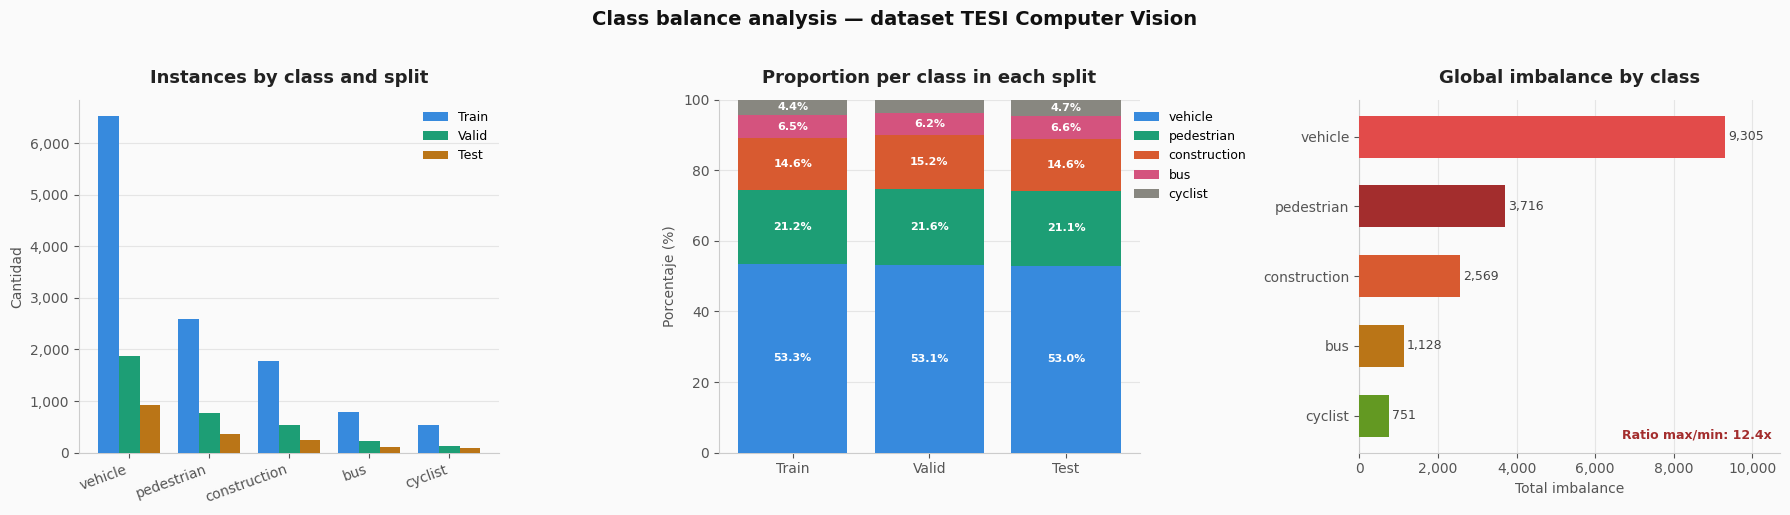

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
class_frecuency_test  = {'bus': 114, 'construction': 254, 'cyclist': 82,  'pedestrian': 368, 'vehicle': 922}
class_frecuency_train = {'bus': 797, 'construction': 1781,'cyclist': 532, 'pedestrian': 2588,'vehicle': 6515}
class_frecuency_valid = {'bus': 217, 'construction': 534, 'cyclist': 137, 'pedestrian': 760, 'vehicle': 1868}

classes = ['vehicle', 'pedestrian', 'construction', 'bus', 'cyclist']

train = [class_frecuency_train[c] for c in classes]
valid = [class_frecuency_valid[c] for c in classes]
test  = [class_frecuency_test[c]  for c in classes]
total = [t + v + te for t, v, te in zip(train, valid, test)]

train_tot = sum(train)
valid_tot = sum(valid)
test_tot  = sum(test)

# Proportion by split
splits      = ['Train', 'Valid', 'Test']
split_tots  = [train_tot, valid_tot, test_tot]
proportions = {
    cls: [
        class_frecuency_train[cls] / train_tot * 100,
        class_frecuency_valid[cls] / valid_tot * 100,
        class_frecuency_test[cls]  / test_tot  * 100,
    ]
    for cls in classes
}

# Colors
COLORS_SPLIT   = {'Train': '#378ADD', 'Valid': '#1D9E75', 'Test': '#BA7517'}
COLORS_CLASS   = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E', '#888780']
COLORS_GLOBAL  = ['#E24B4A', '#A32D2D', '#D85A30', '#BA7517', '#639922']

x      = np.arange(len(classes))
width  = 0.26

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FAFAFA')
for ax in axes:
    ax.set_facecolor('#FAFAFA')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#555555')
    ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# Graph 1: absolute counting by split
ax1 = axes[0]
for i, (split, vals) in enumerate(zip(splits, [train, valid, test])):
    bars = ax1.bar(x + (i - 1) * width, vals, width=width,
                   color=COLORS_SPLIT[split], label=split, zorder=3)

ax1.set_title('Instances by class and split', fontsize=13, fontweight='bold',
              color='#222222', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(classes, rotation=20, ha='right', fontsize=10)
ax1.set_ylabel('Cantidad', fontsize=10, color='#555555')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.legend(frameon=False, fontsize=9)

#  Graph 2: split stacked proportion
ax2 = axes[1]
bottoms = np.zeros(3)
for cls, color in zip(classes, COLORS_CLASS):
    vals = proportions[cls]
    ax2.bar(splits, vals, bottom=bottoms, color=color, label=cls, zorder=3)
    # Label only if there is enough space
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4:
            ax2.text(j, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottoms += np.array(vals)

ax2.set_title('Proportion per class in each split', fontsize=13, fontweight='bold',
              color='#222222', pad=12)
ax2.set_ylabel('Porcentaje (%)', fontsize=10, color='#555555')
ax2.set_ylim(0, 100)
ax2.legend(frameon=False, fontsize=9, loc='upper right',
           bbox_to_anchor=(1.28, 1.0))

# Graph 3: global imbalance (horizontal bars)
ax3 = axes[2]
y_pos = np.arange(len(classes))
bars  = ax3.barh(y_pos, total, color=COLORS_GLOBAL, zorder=3, height=0.6)

for bar, val in zip(bars, total):
    ax3.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9, color='#444444')

ax3.set_title('Global imbalance by class', fontsize=13, fontweight='bold',
              color='#222222', pad=12)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(classes, fontsize=10)
ax3.set_xlabel('Total imbalance', fontsize=10, color='#555555')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax3.set_xlim(0, max(total) * 1.15)
ax3.invert_yaxis()
ax3.xaxis.grid(True, color='#E5E5E5', linewidth=0.8, zorder=0)
ax3.yaxis.grid(False)

# Max/min ratio as annotation
ratio = max(total) / min(total)
ax3.annotate(f'Ratio max/min: {ratio:.1f}x', xy=(0.98, 0.04),
             xycoords='axes fraction', ha='right', fontsize=9,
             color='#A32D2D', fontweight='bold')

plt.suptitle('Class balance analysis — dataset TESI Computer Vision',
             fontsize=14, fontweight='bold', color='#111111', y=1.02)
plt.tight_layout()
plt.savefig('class_balance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# **Global variables for Data-augmentation:**

In [ ]:
from pathlib import Path
from typing import Final

PATH_BASE: Final[Path] = Path.cwd()

PATH_TEST_LABELS_DA:  Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"test_DA"/"labels"
PATH_TRAIN_LABELS_DA: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train_DA"/"labels"
PATH_VALID_LABELS_DA: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid_DA"/"labels"

PATH_TEST_IMAGES_DA:  Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"test_DA"/"images"
PATH_TRAIN_IMAGES_DA: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train_DA"/"images"
PATH_VALID_IMAGES_DA: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid_DA"/"images"

#Others paths real application
PATH_TRAIN_IMAGES_DA_: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train_DA"/"images_DA"
PATH_TRAIN_LABELS_DA_: Final[Path]  =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train_DA"/"labels_DA"

DATASET_PATHS_DA = {
    "test/labels_DA":  PATH_TEST_LABELS_DA,
    "train/labels_DA": PATH_TRAIN_LABELS_DA,
    "valid/labels_DA": PATH_VALID_LABELS_DA,
    "test/images_DA":  PATH_TEST_IMAGES_DA,
    "train/images_DA": PATH_TRAIN_IMAGES_DA,
    "valid/images_DA": PATH_VALID_IMAGES_DA,
    "train/images_DA_": PATH_TRAIN_IMAGES_DA_,
    "train/labels_DA_": PATH_TRAIN_LABELS_DA_,
}

validate_dataset_paths(DATASET_PATHS_DA)

# **Applaying Data-augmentation**

In [ ]:
import os
import cv2
import random
from pathlib import Path
import albumentations as A

import subprocess

## **Data-augmentation**

In [ ]:
from typing import Final

MINORITY_CLASSES: Final[set[int]] = {0, 1, 2, 3}  # ejemplo: bus=0, cyclist=2
MAJORITY_CLASS: Final[list[int]] = [4]               # ejemplo: vehicle=4

AUG_PER_IMAGE: Final[int] = 3  # cuántas nuevas imágenes generar por imagen válida

# =========================
# AUGMENTATIONS
# =========================
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.1,
            rotate_limit=15,
            p=0.5
        ),
        A.MotionBlur(p=0.2),
    ],
    bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])
)


ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


In [ ]:
def load_yolo_labels(label_path:Path) -> tuple[list[list[float]], list[int]]:
    """
    """
    boxes = []
    class_ids = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.strip().split())
            class_ids.append(int(cls))
            boxes.append([x, y, w, h])

    return boxes, class_ids

print(f"Testing method...")
label_path_ = Path("/content/drive/MyDrive/REDES_NEURONALES_2026-1/proyecto-deteccion-localizacion-objetos-urbanos/tesiComputerVisionDatasetV1-1/train_DA/labels/000000_jpeg_jpg.rf.6a4e93cefb04b0e5feadce817c295449.txt")
boxes, class_ids = load_yolo_labels(label_path_)
print(f"boxes: {boxes}")
print(f"class_ids: {class_ids}")

Testing method...
boxes: [[0.9580965909090909, 0.4318181818181818, 0.078125, 0.07528409090909091], [0.8764204545454546, 0.4133522727272727, 0.11789772727272728, 0.08664772727272728], [0.8622159090909091, 0.7201704545454546, 0.26988636363636365, 0.1846590909090909], [0.7372159090909091, 0.48011363636363635, 0.15625, 0.08238636363636363], [0.46875, 0.45951704545454547, 0.13636363636363635, 0.05113636363636364], [0.49857954545454547, 0.5127840909090909, 0.16335227272727273, 0.08806818181818182], [0.009943181818181818, 0.34375, 0.019886363636363636, 0.06960227272727272], [0.6924715909090909, 0.4346590909090909, 0.1434659090909091, 0.09375], [0.18323863636363635, 0.8366477272727273, 0.36079545454545453, 0.26420454545454547], [0.5610795454545454, 0.5973011363636364, 0.21306818181818182, 0.13210227272727273]]
class_ids: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [ ]:
def is_valid_image(class_ids: list[int], minority_classes: set[int],
                    majority_classes: list[int]) -> bool:
    """
    """
    valid_img: bool = True
    class_set = set(class_ids)

    # Debe contener SOLO clases minoritarias
    if not class_set.issubset(minority_classes):
      valid_img = False

    # No debe contener clase dominante
    if class_set.intersection(majority_classes):
      valid_img = False

    return valid_img

print(f"Testing method...")
class_ids = [1,2,3,3,3,3,1]
print(f"is_valid_image: {is_valid_image(class_ids, MINORITY_CLASSES, MAJORITY_CLASS)}")

Testing method...
is_valid_image: True


In [ ]:
def save_yolo_labels(path:Path, boxes: list[list[float]], class_ids: list[int]):
    with open(path, "w") as f:
        for cls, box in zip(class_ids, boxes):
            f.write(f"{cls} {' '.join(map(str, box))}\n")

In [ ]:

def apply_augmentation(images_path: Path, labels_path: Path, aug_per_image:int,
                       dir_img_created:Path, dir_label_created:Path) -> None:

  images: list[Path] = list(images_path.glob('*.jpg'))
  labels: list[Path] = list(labels_path.glob('*.txt'))
  #print(f"Number of images: {len(images)}")
  #print(f"Number of labels: {len(labels)}")

  if len(images) != len(labels):
    raise ValueError("Number of images and labels must be the same")
  if len(images) == 0:
    raise ValueError("No images found")
  if len(labels) == 0:
    raise ValueError("No labels found")

  for i, (img, lbl) in enumerate(zip(images, labels)):
      #print(f"{i} - IMAGE: {img}")
      #print(f"{i} - IMAGE: {img.name} - LABEL: {lbl.name}")
      if not img.exists() or not lbl.exists():
        #print(f"IMAGE: {img.name} not exist, or LABEL: {lbl.name} not exist")
        continue


      boxes, class_ids = load_yolo_labels(lbl)

      if not is_valid_image(class_ids, MINORITY_CLASSES, MAJORITY_CLASS):
        #print(f"IMAGE: {img.name} is not valid, it has majority class")
        continue

      image = cv2.imread(str(img))

      for i in range(AUG_PER_IMAGE):
        augmented = transform(
            image=image,
            bboxes=boxes,
            class_labels=class_ids
        )

        aug_img = augmented["image"]
        aug_boxes = augmented["bboxes"]
        aug_classes = augmented["class_labels"]

        new_name = f"{img.stem}_aug_{i}.jpg"

        cv2.imwrite(str(dir_img_created / new_name), aug_img)
        save_yolo_labels(
            dir_label_created / (Path(new_name).stem + ".txt"),
            aug_boxes,
            aug_classes
        )


In [ ]:
print(f"Applaying data-augmentation on train dataset...")
print(f"Number of images per image: {AUG_PER_IMAGE}")
print(f"Minority classes: {MINORITY_CLASSES}")
print(f"Majority classes: {MAJORITY_CLASS}")

img_path_created:Path= PATH_TRAIN_IMAGES_DA_
labels_path_created:Path= PATH_TRAIN_LABELS_DA_

apply_augmentation(PATH_TRAIN_IMAGES_DA, PATH_TRAIN_LABELS_DA, AUG_PER_IMAGE, img_path_created, labels_path_created)

Applaying data-augmentation on train dataset...
Number of images per image: 3
Minority classes: {0, 1, 2, 3}
Majority classes: [4]


#**Counting classes from images after Data-augmentation**

In [ ]:
from collections import Counter

# class frecuency in train subset before DA
class_frecuency_train_bDA = {'bus': 797, 'construction': 1781,'cyclist': 532, 'pedestrian': 2588,'vehicle': 6515}

# class frecuency in train subset after DA
class_frecuency_train_aDA: Final[dict[str, int]] = counting_classes_frecuency(PATH_TRAIN_LABELS_DA_, CLASSES_NUMBERS)
print(f"Train class frecuency of after DA train-subsate: {class_frecuency_train_aDA} \n")

global_class_train_frecuency_aDA: Final[dict[str, int]] = Counter(class_frecuency_train_bDA) + Counter(class_frecuency_train_aDA)
print(f"Tha global amount of images of each class is: {global_class_train_frecuency} \n")

Train class frecuency of after DA train-subsate: {'bus': 45, 'construction': 339, 'cyclist': 102, 'pedestrian': 251, 'vehicle': 0} 

Tha global amount of images of each class is: Counter({'vehicle': 6515, 'pedestrian': 2839, 'construction': 2120, 'bus': 842, 'cyclist': 634}) 



In [ ]:
class_frecuency_train_bDA = {'bus': 797, 'construction': 1781,'cyclist': 532, 'pedestrian': 2588,'vehicle': 6515}

global_class_train_frecuency_aDA = {'vehicle': 6515, 'pedestrian': 2839, 'construction': 2120, 'bus': 842, 'cyclist': 634}

# **Count class graph per image after DA** *in train subsate*

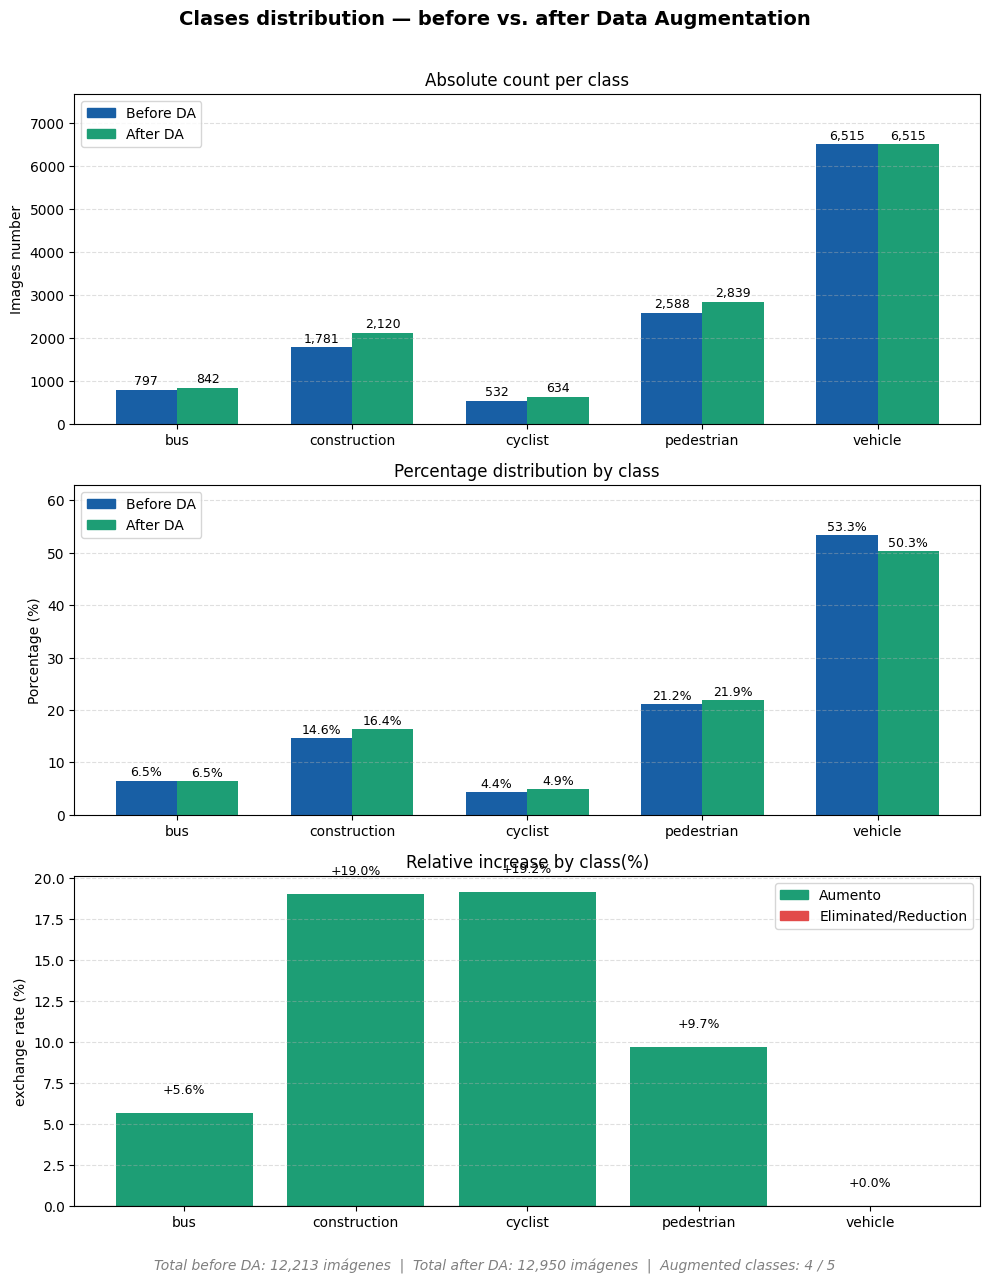

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
class_freq_before = {
    'bus': 797,
    'construction': 1781,
    'cyclist': 532,
    'pedestrian': 2588,
    'vehicle': 6515
    }

class_freq_after = {
    'vehicle': 6515,
    'pedestrian': 2839,
    'construction': 2120,
    'bus': 842,
    'cyclist': 634
    }

# Preparation
classes  = list(class_freq_before.keys())
before   = np.array([class_freq_before[c] for c in classes])
after    = np.array([class_freq_after[c]  for c in classes])

total_b  = before.sum()
total_a  = after.sum()
pct_b    = before / total_b * 100
pct_a    = after  / total_a * 100

# Incremento relativo (None si la clase se eliminó)
delta = np.where(before > 0, (after - before) / before * 100, np.nan)

COLOR_B  = '#185FA5'   # azul  – antes DA
COLOR_A  = '#1D9E75'   # verde – después DA
COLOR_UP = '#1D9E75'
COLOR_DN = '#E24B4A'

x      = np.arange(len(classes))
width  = 0.35

# Figure
fig, axes = plt.subplots(3, 1, figsize=(10, 13))
fig.suptitle('Clases distribution — before vs. after Data Augmentation',
             fontsize=14, fontweight='bold', y=0.98)

legend_patches = [
    mpatches.Patch(color=COLOR_B, label='Before DA'),
    mpatches.Patch(color=COLOR_A, label='After DA'),
]

# Absolute counting
ax1 = axes[0]
bars_b = ax1.bar(x - width/2, before, width, color=COLOR_B, label='Before DA')
bars_a = ax1.bar(x + width/2, after,  width, color=COLOR_A, label='After DA')

for bar in bars_b:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars_a:
    h = bar.get_height()
    label = '0\n(deletated)' if h == 0 else f'{int(h):,}'
    ax1.text(bar.get_x() + bar.get_width()/2, h + 50,
             label, ha='center', va='bottom', fontsize=9,
             color=COLOR_DN if h == 0 else 'black')

ax1.set_title('Absolute count per class', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(classes)
ax1.set_ylabel('Images number')
ax1.legend(handles=legend_patches)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_ylim(0, max(before.max(), after.max()) * 1.18)

# Porcentual distribution
ax2 = axes[1]
ax2.bar(x - width/2, pct_b, width, color=COLOR_B, label='Before DA')
ax2.bar(x + width/2, pct_a, width, color=COLOR_A, label='After DA')

for xi, (pb, pa) in enumerate(zip(pct_b, pct_a)):
    ax2.text(xi - width/2, pb + 0.3, f'{pb:.1f}%', ha='center', va='bottom', fontsize=9)
    ax2.text(xi + width/2, pa + 0.3, f'{pa:.1f}%', ha='center', va='bottom', fontsize=9,
             color=COLOR_DN if pa == 0 else 'black')

ax2.set_title('Percentage distribution by class', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(classes)
ax2.set_ylabel('Porcentage (%)')
ax2.legend(handles=legend_patches)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, max(pct_b.max(), pct_a.max()) * 1.18)

# Relative increase
ax3 = axes[2]
colors_delta = [COLOR_UP if (not np.isnan(d) and d >= 0) else COLOR_DN for d in delta]
bars_d = ax3.bar(x, delta, color=colors_delta)

for bar, d in zip(bars_d, delta):
    if np.isnan(d):
        ax3.text(bar.get_x() + bar.get_width()/2, 2,
                 'delated', ha='center', va='bottom', fontsize=9, color=COLOR_DN)
    else:
        ypos = d + 1 if d >= 0 else d - 3
        ax3.text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{d:+.1f}%', ha='center', va='bottom', fontsize=9)

ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Relative increase by class(%)', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(classes)
ax3.set_ylabel('exchange rate (%)')
ax3.grid(axis='y', linestyle='--', alpha=0.4)

up_patch = mpatches.Patch(color=COLOR_UP, label='Aumento')
dn_patch = mpatches.Patch(color=COLOR_DN, label='Eliminated/Reduction')
ax3.legend(handles=[up_patch, dn_patch])

# Summary metrics in figure caption
summary = (f'Total before DA: {total_b:,} imágenes  |  '
           f'Total after DA: {total_a:,} imágenes  |  '
           f'Augmented classes: {int((after > before).sum())} / {len(classes)}')
fig.text(0.5, 0.01, summary, ha='center', fontsize=10,
         color='gray', style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
#plt.savefig('class_distribution_DA.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Gráfica guardada como class_distribution_DA.png")

# **Global variables for oversampling**

In [ ]:
from pathlib import Path
from typing import Final

PATH_BASE: Final[Path] = Path.cwd()

PATH_TRAIN_LABELS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"labels"

PATH_TRAIN_IMAGES: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"images"

#
PATH_TRAIN_LABELS_OS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"labels_OS"
PATH_TRAIN_IMAGES_OS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"train"/"images_OS"

#
PATH_VALID_LABELS_OS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid"/"labels_OS"
PATH_VALID_IMAGES_OS: Final[Path] =  PATH_BASE / "tesiComputerVisionDatasetV1-1"/"valid"/"images_OS"


DATASET_PATHS_OS = {
    "train/labels": PATH_TRAIN_LABELS,
    "train/images": PATH_TRAIN_IMAGES,
    "train/labels_OS": PATH_TRAIN_LABELS_OS,
    "train/images_OS": PATH_TRAIN_IMAGES_OS,
    "valid/labels_OS": PATH_VALID_LABELS_OS,
    "valid/images_OS": PATH_VALID_IMAGES_OS
}

validate_dataset_paths(DATASET_PATHS_OS)

# **Oversamplig application**

In [ ]:
def get_class_ids_from_label(label_path: Path) -> set[int]:
    """
    """
    class_ids = set()

    if not label_path.exists():
        return class_ids

    with open(label_path, "r") as f:
        for line in f:
            if line.strip():
                class_id = int(float(line.split()[0]))
                class_ids.add(class_id)

    return class_ids

In [ ]:
def should_duplicate(class_ids: set[int], minority_classes: set[int],
                     majority_classes: set[int]) -> bool:
    """
    """
    if not minority_classes or not majority_classes:
        return False

    has_minority = len(class_ids & minority_classes) > 0
    has_majority = len(class_ids & majority_classes) > 0

    return has_minority and not has_majority

In [ ]:
import shutil

def duplicate_images(images_dir: Path, labels_dir: Path, output_images_dir: Path,
                     output_labels_dir: Path,minority_classes: set[int],
                     majority_classes: set[int], duplication_factor: int) -> None:

  images: list[Path] = list(images_dir.glob('*.jpg'))
  labels: list[Path] = list(labels_dir.glob('*.txt'))
  print(f"Number of images: {len(images)}")
  print(f"Number of labels: {len(labels)}")

  if len(images) != len(labels):
    raise ValueError("Number of images and labels must be the same")
  if len(images) == 0:
    raise ValueError("No images found")
  if len(labels) == 0:
    raise ValueError("No labels found")

  for i, (img, lbl) in enumerate(zip(images, labels)):
    if not img.exists() or not lbl.exists():
      continue

    class_ids = get_class_ids_from_label(lbl)

    if not should_duplicate(class_ids, minority_classes, majority_classes):
      continue

    for i in range(1, duplication_factor):
      new_image_name = f"{img.stem}_dup{i}{img.suffix}"
      new_label_name = f"{lbl.stem}_dup{i}.txt"

      new_image_path = output_images_dir / new_image_name
      new_label_path = output_labels_dir / new_label_name

      shutil.copy(img, new_image_path)

      if lbl.exists():
          shutil.copy(lbl, new_label_path)


In [ ]:
MINORITY_CLASSES = {0, 1, 2, 3}
MAJORITY_CLASSES = {4}
DUPLICATION_FACTOR = 3

print(f"Oversampling images from train-subset...")
print(f"Minority classes: {MINORITY_CLASSES}")
print(f"Majority classes: {MAJORITY_CLASSES}")
print(f"Duplication factor: {DUPLICATION_FACTOR}")

duplicate_images(PATH_TRAIN_IMAGES, PATH_TRAIN_LABELS, PATH_TRAIN_IMAGES_OS,
                 PATH_TRAIN_LABELS_OS,MINORITY_CLASSES, MAJORITY_CLASSES, DUPLICATION_FACTOR)

Oversampling images from train-subset...
Minority classes: {0, 1, 2, 3}
Majority classes: {4}
Duplication factor: 3
Number of images: 6709
Number of labels: 6709


# **YOLO application** *yolov8s*

In [ ]:
from ultralytics import YOLO
import ultralytics

print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.41


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from ultralytics import YOLO
from pathlib import Path
from typing import Final

BASE_PATH_DATA: Final[Path] = Path.cwd()

BASE_PATH: Final[Path] = Path.cwd()
DATA_FILE: Final[Path] = BASE_PATH / "dataModel.yaml"
PROJECT_DIR: Final[Path] = BASE_PATH / "runs"
WEIGHTS_DIR: Final[Path] = PROJECT_DIR / "weights"

WEIGHTS_DIR.mkdir(exist_ok=True)


model = YOLO("yolov8s.pt")

model = model.train(
    data=DATA_FILE,
    epochs=70,
    imgsz=640,
    batch=16,
    cls=2.0,

    project=str(PROJECT_DIR),
    exist_ok=True,
    save=True,
    verbose=False
)

# **Results**

## Training Results — YOLOv8s

## Experiment Configuration

| Parameter | Value |
|---|---|
| Base model | `yolov8s.pt` (pretrained) |
| Epochs | 70 |
| Image size | 640 × 640 |
| Batch size | 16 |
| Optimizer | AdamW (lr=0.001111, momentum=0.9) |
| Classes | 5 |
| Training images | 7,679 (6,709 annotated + 970 backgrounds) |
| Validation images | 1,920 |
| Hardware | NVIDIA A100-SXM4-80GB |
| Total training time | 1.41 hours |

---

## Overall Metrics (Best Model)

| Metric | Value |
|---|---|
| Precision (P) | **81.9%** |
| Recall (R) | **72.6%** |
| mAP@50 | **79.9%** |
| mAP@50-95 | **50.8%** |
| Fitness | 0.5080 |

> Best checkpoint saved at `runs/detect/train/weights/best.pt` (22.5 MB).

---

## Per-Class Metrics (Best Model)

| Class | Instances (val) | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---:|---:|---:|---:|---:|
| bus | 281 | 82.0% | 81.5% | 85.8% | 65.6% |
| construction | 2,637 | 76.9% | 64.6% | 72.6% | 37.4% |
| cyclist | 221 | 75.9% | 65.7% | 71.1% | 46.4% |
| pedestrian | 3,304 | 84.2% | 67.8% | 78.3% | 42.0% |
| vehicle | 18,390 | 90.6% | 83.4% | 91.6% | 62.5% |
| **all** | **24,833** | **81.9%** | **72.6%** | **79.9%** | **50.8%** |

---

## mAP Training Progression

| Epoch | mAP@50 | mAP@50-95 |
|---:|---:|---:|
| 1 | 0.495 | 0.248 |
| 10 | 0.620 | 0.352 |
| 20 | 0.706 | 0.414 |
| 30 | 0.752 | 0.452 |
| 40 | 0.779 | 0.481 |
| 50 | 0.792 | 0.497 |
| 60 | 0.798 | 0.508 |
| 70 | 0.800 | 0.508 |

---

## Observations

- **`vehicle`** is the best-performing class (mAP@50 = 91.6%), benefiting from its dominant representation in the dataset (18,390 instances).
- **`bus`** achieves the highest mAP@50-95 (65.6%), indicating strong localization precision in addition to accurate detection.
- **`construction`** has the lowest recall (64.6%), suggesting a higher false negative rate, likely due to the visual heterogeneity of construction-related objects.
- **`cyclist`** and **`pedestrian`** show expected cross-confusion due to morphological similarity, reflected in their moderate recall scores.
- The model converges steadily across all 70 epochs with no clear signs of overfitting.

## Confusion Matrix — YOLOv8s

> Source: `runs/detect/train/confusion_matrix.png` and `confusion_matrix_normalized.png`

---

## Raw Counts

| Predicted \ True | bus | construction | cyclist | pedestrian | vehicle | background |
|---|:---:|:---:|:---:|:---:|:---:|:---:|
| **bus** | **228** | 0 | 0 | 0 | 26 | 63 |
| **construction** | 0 | **2026** | 0 | 3 | 8 | 1081 |
| **cyclist** | 0 | 0 | **151** | 32 | 6 | 45 |
| **pedestrian** | 4 | 41 | 2497 | **2497** | 9 | 793 |
| **vehicle** | 35 | 1 | 2 | 7 | **16207** | 2807 |
| **background (FN)** | 18 | 606 | 27 | 765 | 2134 | — |

---

## Normalized Confusion Matrix

> Values represent the proportion of ground truth instances per class.
> Cells with value 0.00 are omitted for readability.

| Predicted \ True | bus | construction | cyclist | pedestrian | vehicle | background |
|---|:---:|:---:|:---:|:---:|:---:|:---:|
| **bus** | **0.81** | — | — | — | — | 0.01 |
| **construction** | — | **0.77** | — | — | — | 0.23 |
| **cyclist** | — | — | **0.68** | 0.01 | — | 0.01 |
| **pedestrian** | — | — | 0.19 | **0.76** | — | 0.17 |
| **vehicle** | 0.12 | — | 0.01 | — | **0.88** | 0.59 |
| **background (FN)** | 0.06 | 0.23 | 0.12 | 0.23 | 0.12 | — |

---

## Per-Class Summary

| Class | TP Rate (diagonal) | Main confusion | FN Rate (→ background) |
|---|:---:|---|:---:|
| bus | 0.81 | Confused with `vehicle` (0.12) | 0.06 |
| construction | 0.77 | Lost to background (0.23) | 0.23 |
| cyclist | 0.68 | Confused with `pedestrian` (0.19) | 0.12 |
| pedestrian | 0.76 | Confused with `cyclist` (0.19) | 0.23 |
| vehicle | 0.88 | Confused with `background` (0.12) | 0.12 |

---

## Key Takeaways

- **`vehicle`** is the best-detected class (TP = 0.88), but a significant share of background instances are incorrectly predicted as vehicle (0.59), indicating the model is somewhat trigger-happy on this dominant class.
- **`bus`** has a solid TP rate (0.81) but is frequently confused with `vehicle` (0.12), which is expected given their visual overlap. Its FN rate is low (0.06).
- **`construction`** scores 0.77 on the diagonal but loses 23% of instances to background (FN = 0.23), reflecting the visual heterogeneity of this class.
- **`cyclist`** and **`pedestrian`** show strong mutual confusion: 19% of cyclists are predicted as pedestrians and vice versa. This is the most prominent inter-class error in the model.
- **`pedestrian`** also suffers a high false negative rate (0.23), tied with `construction` as the most-missed class.